# Gig Worker Income — Volatility Classification Model
**Random Forest | Multi-Platform | One Final Summary Row per Dataset**

| Step | Description |
|------|-------------|
| 1 | Load & combine all 5 platform CSVs |
| 2 | Statistical label verification (Mean / Std / CV rules) |
| 3 | Feature Engineering (rolling stats, diffs, flags) |
| 4 | Train Random Forest + evaluate |
| 5 | **Single summary output per dataset** — Volatility Class + Confidence Score |
| 6 | Export one-row-per-platform summary CSV |

---
##  Step 0 — Imports & Config

In [19]:
# %pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── CONFIG ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('.')        # folder containing the 5 CSVs
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

PLATFORMS = ['blinkit', 'snabbit', 'swiggy', 'uber', 'zomato']
CV_LOW    = 0.30
CV_MEDIUM = 0.60

RF_PARAMS = dict(
    n_estimators     = 200,
    max_depth        = None,
    min_samples_leaf = 2,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,
)

PALETTE = {'low': '#4caf50', 'medium': '#ff9800', 'high': '#f44336'}

print('  Ready.')

  Ready.


---
##  Step 1 — Load & Combine Datasets

In [20]:
dfs = []
for platform in PLATFORMS:
    fpath = DATA_DIR / f'{platform}_with_volatility_label.csv'
    df    = pd.read_csv(fpath, parse_dates=['date'])
    df['platform'] = platform
    dfs.append(df)
    print(f'  ✔ {platform:10s}: {len(df)} rows')

raw = pd.concat(dfs, ignore_index=True)
raw.sort_values(['platform', 'date'], inplace=True)
raw.reset_index(drop=True, inplace=True)
print(f'\n  Combined: {raw.shape[0]} rows × {raw.shape[1]} cols')

  ✔ blinkit   : 120 rows
  ✔ snabbit   : 120 rows
  ✔ swiggy    : 120 rows
  ✔ uber      : 120 rows
  ✔ zomato    : 120 rows

  Combined: 600 rows × 11 cols


---
##  Step 2 — Statistical Label Generation + Verification

We generate a new day-level label using rolling CV rules and append it into each existing dataset as a new column:
`volatility_label_stat` (low / medium / high).

| Metric | Description |
|--------|-------------|
| **Mean income** | Central tendency across all days |
| **Std deviation** | Spread of daily income |
| **CV = std / mean** | Normalized volatility rule driver |

```
CV < 0.30          ->  low
0.30 <= CV < 0.60  ->  medium
CV >= 0.60         ->  high
```

In [21]:
def cv_to_label(cv):
    if cv < CV_LOW:
        return 'low'
    if cv < CV_MEDIUM:
        return 'medium'
    return 'high'

# Platform-level stats (for quick verification)
rows = []
for platform, grp in raw.groupby('platform'):
    m = grp['income'].mean()
    s = grp['income'].std()
    cv = s / m if m else 0
    rows.append({
        'Platform': platform,
        'Mean Income': round(m, 2),
        'Std Dev': round(s, 2),
        'CV': round(cv, 4),
        'Platform CV Label': cv_to_label(cv),
    })

display(pd.DataFrame(rows).set_index('Platform'))

# Day-level statistical label using rolling CV (used as ML target)
g = raw.groupby('platform')['income']
raw['rolling_mean_7'] = g.transform(lambda x: x.rolling(7, min_periods=1).mean())
raw['rolling_std_7'] = g.transform(lambda x: x.rolling(7, min_periods=2).std().fillna(0))
raw['rolling_cv_7'] = (raw['rolling_std_7'] / raw['rolling_mean_7'].replace(0, np.nan)).fillna(0)
raw['volatility_label_stat'] = raw['rolling_cv_7'].apply(cv_to_label)

# Compare existing label with generated statistical label (if existing is present)
if 'volatility_label' in raw.columns:
    agreement_pct = (raw['volatility_label'] == raw['volatility_label_stat']).mean() * 100
    print(f"\nExisting label vs generated statistical label agreement: {agreement_pct:.1f}%")

# Write back the new column into each existing dataset as the next column
for platform, grp in raw.groupby('platform'):
    fpath = DATA_DIR / f'{platform}_with_volatility_label.csv'
    out_df = grp.copy()

    # Keep the schema tidy and ensure new statistical label appears immediately
    # after the existing 'volatility_label' column when available.
    preferred_order = ['date', 'day_of_week', 'income', 'platform', 'hours_worked', 'orders_completed']
    if 'volatility_label' in out_df.columns:
        preferred_order.append('volatility_label')
    preferred_order.append('volatility_label_stat')

    remaining_cols = [c for c in out_df.columns if c not in preferred_order]
    ordered_cols = [c for c in preferred_order if c in out_df.columns] + remaining_cols
    out_df = out_df[ordered_cols]
    out_df.to_csv(fpath, index=False)

print("Generated 'volatility_label_stat' and updated all source CSV files.")

,Mean Income,Std Dev,CV,Platform CV Label
Platform,,,,
blinkit,1511.97,1059.23,0.7006,high
snabbit,648.86,684.21,1.0545,high
swiggy,1086.38,985.24,0.9069,high
uber,1717.90,1228.70,0.7152,high
zomato,1178.50,1261.70,1.0706,high



Existing label vs generated statistical label agreement: 38.2%
Generated 'volatility_label_stat' and updated all source CSV files.


---
##  Step 3 — Feature Engineering

In [22]:
def engineer_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values(['platform', 'date'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    g = df.groupby('platform')['income']

    df['rolling_mean_7'] = g.transform(lambda x: x.rolling(7, min_periods=1).mean())
    df['rolling_std_7'] = g.transform(lambda x: x.rolling(7, min_periods=2).std().fillna(0))
    df['income_diff'] = g.transform(lambda x: x.diff().fillna(0))
    df['zero_income_days_last_7'] = g.transform(lambda x: (x == 0).rolling(7, min_periods=1).sum())
    df['max_income_last_7'] = g.transform(lambda x: x.rolling(7, min_periods=1).max())
    df['min_income_last_7'] = g.transform(lambda x: x.rolling(7, min_periods=1).min())
    df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
    df['income_range_7'] = df['max_income_last_7'] - df['min_income_last_7']
    df['cv_7'] = (df['rolling_std_7'] / df['rolling_mean_7'].replace(0, np.nan)).fillna(0)
    df['platform_code'] = df['platform'].astype('category').cat.codes
    return df

df_feat = engineer_features(raw)

FEATURE_COLS = [
    'rolling_mean_7', 'rolling_std_7', 'income_diff',
    'zero_income_days_last_7', 'max_income_last_7', 'min_income_last_7',
    'is_weekend', 'income_range_7', 'cv_7', 'platform_code',
]
TARGET_COL = 'volatility_label_stat'
print(f'  Feature matrix: {df_feat[FEATURE_COLS].shape}')
print(f'  Target column : {TARGET_COL}')

  Feature matrix: (600, 10)
  Target column : volatility_label_stat


---
##    Step 4 — Train Random Forest

MODEL ACCURACY
5-Fold CV Accuracy  : 0.9933 +/- 0.0062
Individual folds    : Fold 1: 1.0000  Fold 2: 1.0000  Fold 3: 0.9833  Fold 4: 0.9917  Fold 5: 0.9917
Test Accuracy       : 0.9833

              precision    recall  f1-score   support

        high       0.99      0.99      0.99        89
         low       1.00      1.00      1.00         5
      medium       0.96      0.96      0.96        26

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



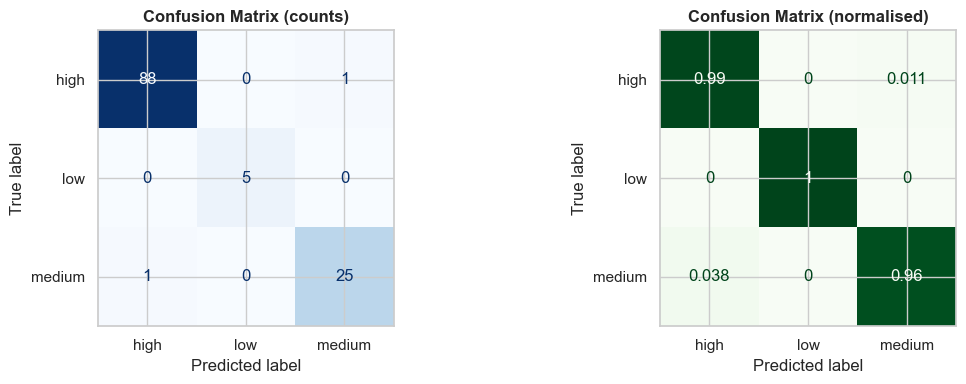

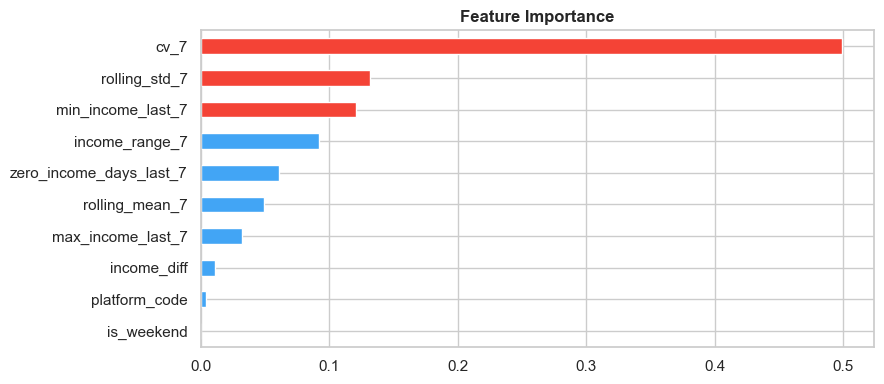

In [23]:
le = LabelEncoder()
le.fit(['low', 'medium', 'high'])

X = df_feat[FEATURE_COLS].values
y = le.transform(df_feat[TARGET_COL])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf = RandomForestClassifier(**RF_PARAMS)
rf.fit(X_train, y_train)

cv_scores = cross_val_score(
    rf, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
y_pred   = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print('=' * 55)
print('MODEL ACCURACY')
print('=' * 55)
print(f'5-Fold CV Accuracy  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
fold_str = '  '.join([f'Fold {i+1}: {s:.4f}' for i, s in enumerate(cv_scores)])
print(f'Individual folds    : {fold_str}')
print(f'Test Accuracy       : {test_acc:.4f}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=le.classes_).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize='true'),
                       display_labels=le.classes_).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
colors = ['#f44336' if i >= len(imp)-3 else '#42a5f5' for i in range(len(imp))]
fig, ax = plt.subplots(figsize=(9, 4))
imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  Step 5 — Final Single Output per Dataset

Instead of showing a row per day, we collapse all days into **one summary row per platform**.  
The model votes across every day's prediction → majority class = final label.  
Confidence = average `predict_proba` score for the winning class.


In [24]:
# -- 1. Row-level predictions -------------------------------------------------
proba    = rf.predict_proba(X)
pred_enc = rf.predict(X)

df_feat = df_feat.copy()
df_feat['predicted_label']  = le.inverse_transform(pred_enc)
df_feat['confidence_score'] = proba.max(axis=1).round(4)
df_feat['prob_low']         = proba[:, le.transform(['low'])[0]].round(4)
df_feat['prob_medium']      = proba[:, le.transform(['medium'])[0]].round(4)
df_feat['prob_high']        = proba[:, le.transform(['high'])[0]].round(4)

# -- 2. Helper: build one summary row from a group ----------------------------
def build_summary_row(platform_name, grp):
    mean_income  = grp['income'].mean()
    std_income   = grp['income'].std()
    cv           = std_income / mean_income if mean_income else 0
    total_income = grp['income'].sum()
    zero_days    = (grp['income'] == 0).sum()
    total_days   = len(grp)

    label_counts   = grp['predicted_label'].value_counts()
    final_label    = label_counts.idxmax()
    label_pct      = label_counts / label_counts.sum()

    winning_col    = f'prob_{final_label}'
    avg_confidence = grp[winning_col].mean()

    stat_label_global = cv_to_label(cv)

    return {
        'Platform'             : platform_name,
        'Total Days'           : total_days,
        'Total Income (Rs)'    : round(total_income, 2),
        'Mean Income (Rs)'     : round(mean_income, 2),
        'Std Dev (Rs)'         : round(std_income, 2),
        'CV'                   : round(cv, 4),
        'Zero Income Days'     : int(zero_days),
        'Stat Label (CV rule)' : stat_label_global,
        'Days Low (%)'         : round(label_pct.get('low',    0) * 100, 1),
        'Days Medium (%)'      : round(label_pct.get('medium', 0) * 100, 1),
        'Days High (%)'        : round(label_pct.get('high',   0) * 100, 1),
        'Final Volatility'     : final_label.upper(),
        'Confidence Score'     : round(avg_confidence, 4),
    }

# -- 3. Per-platform rows + one ALL-PLATFORMS aggregate row -------------------
summary_rows = []
for platform, grp in df_feat.groupby('platform'):
    summary_rows.append(build_summary_row(platform, grp))

# All-platforms combined row
summary_rows.append(build_summary_row('ALL PLATFORMS', df_feat))

summary = pd.DataFrame(summary_rows).set_index('Platform')

print('=' * 70)
print('        FINAL VOLATILITY CLASSIFICATION — ONE ROW PER DATASET')
print('=' * 70)
display(summary)
print('=' * 70)


        FINAL VOLATILITY CLASSIFICATION — ONE ROW PER DATASET


,Total Days,Total Income (Rs),Mean Income (Rs),Std Dev (Rs),CV,Zero Income Days,Stat Label (CV rule),Days Low (%),Days Medium (%),Days High (%),Final Volatility,Confidence Score
Platform,,,,,,,,,,,,
blinkit,120,181436.36,1511.97,1059.23,0.7006,13,high,7.5,31.7,60.8,HIGH,0.6047
snabbit,120,77863.73,648.86,684.21,1.0545,28,high,0.8,11.7,87.5,HIGH,0.8657
swiggy,120,130366.19,1086.38,985.24,0.9069,19,high,0.8,22.5,76.7,HIGH,0.7638
uber,120,206148.22,1717.90,1228.70,0.7152,11,high,6.7,30.0,63.3,HIGH,0.6366
zomato,120,141420.18,1178.50,1261.70,1.0706,20,high,5.0,14.2,80.8,HIGH,0.8083
ALL PLATFORMS,600,737234.68,1228.72,1122.88,0.9139,91,high,4.2,22.0,73.8,HIGH,0.7358


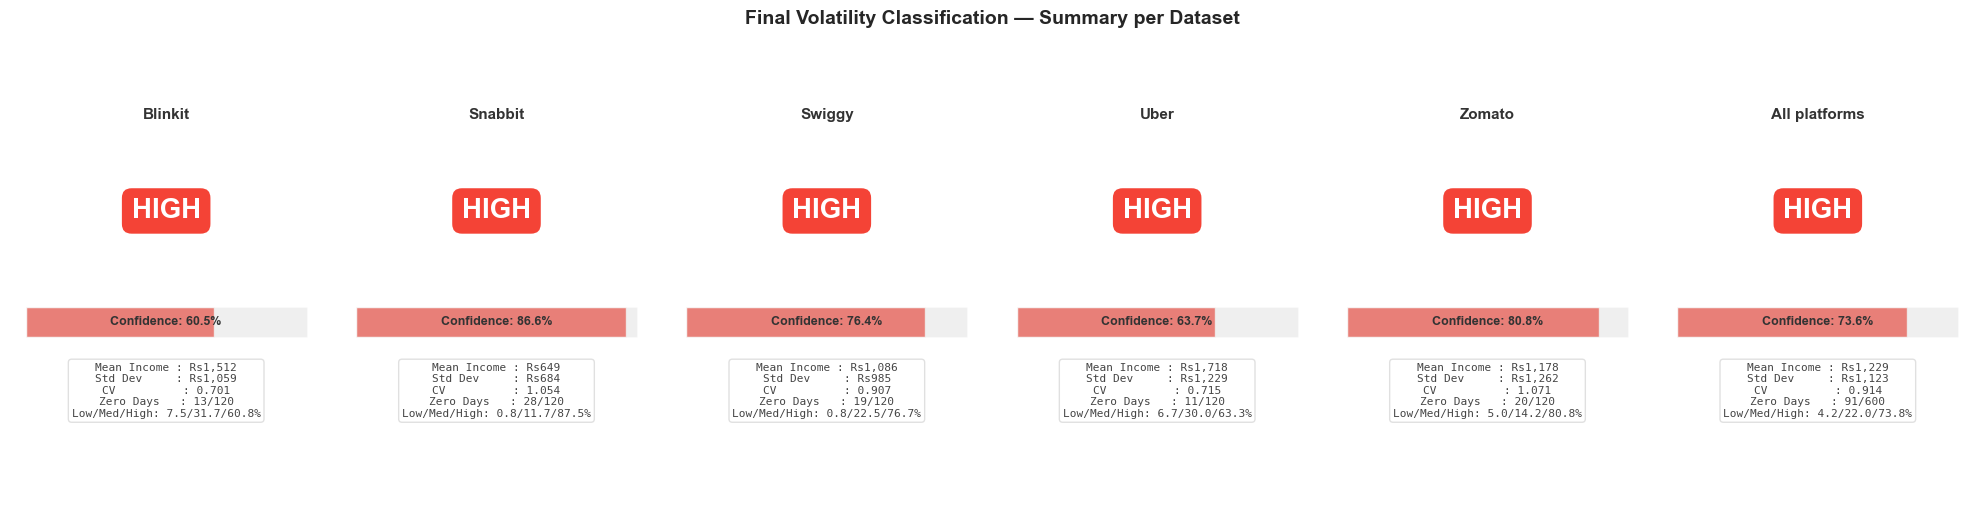

In [25]:
# -- Dashboard: one card per platform + all-platforms ------------------------
all_platforms_list = PLATFORMS + ['ALL PLATFORMS']
fig, axes = plt.subplots(1, len(all_platforms_list), figsize=(20, 5))
fig.suptitle('Final Volatility Classification — Summary per Dataset',
             fontsize=14, fontweight='bold', y=1.02)

LABEL_COLOR = {'LOW': '#4caf50', 'MEDIUM': '#ff9800', 'HIGH': '#f44336'}

for ax, platform_name in zip(axes, all_platforms_list):
    row         = summary.loc[platform_name]
    final_label = row['Final Volatility']
    confidence  = row['Confidence Score']
    bg_color    = LABEL_COLOR[final_label]

    ax.set_facecolor(bg_color + '22')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    ax.text(0.5, 0.92, platform_name.capitalize(),
            ha='center', va='top', fontsize=11, fontweight='bold',
            color='#333333')

    ax.text(0.5, 0.68, final_label,
            ha='center', va='center', fontsize=20, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_color,
                      edgecolor='white', linewidth=2))

    bar_w = confidence
    ax.barh(0.42, bar_w, left=0.05, height=0.07,
            color=bg_color, alpha=0.85)
    ax.barh(0.42, 0.90, left=0.05, height=0.07,
            color='#cccccc', alpha=0.3)
    ax.text(0.5, 0.42, f'Confidence: {confidence:.1%}',
            ha='center', va='center', fontsize=9, color='#333333', fontweight='bold')

    stats_text = (
        f"Mean Income : Rs{row['Mean Income (Rs)']:,.0f}\n"
        f"Std Dev     : Rs{row['Std Dev (Rs)']:,.0f}\n"
        f"CV          : {row['CV']:.3f}\n"
        f"Zero Days   : {row['Zero Income Days']}/{row['Total Days']}\n"
        f"Low/Med/High: {row['Days Low (%)']}/{row['Days Medium (%)']}/{row['Days High (%)']}%"
    )
    ax.text(0.5, 0.26, stats_text,
            ha='center', va='center', fontsize=8,
            color='#444444', family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='#cccccc'))

    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(bg_color)
        ax.spines[spine].set_linewidth(2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


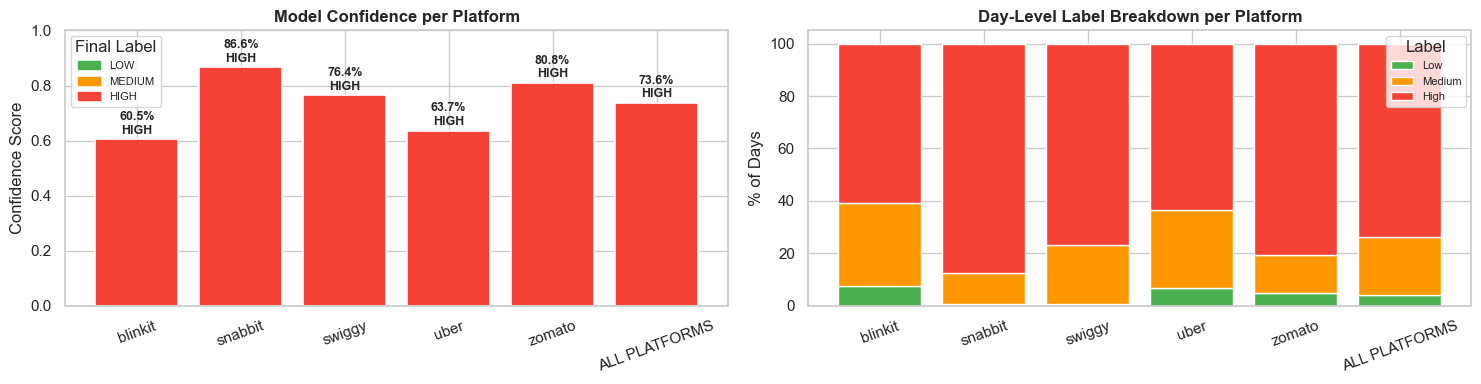

In [26]:
# -- Bar chart: confidence by platform ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

plot_platforms = summary.index.tolist()
labels         = summary['Final Volatility'].tolist()
confidences    = summary['Confidence Score'].tolist()
bar_colors     = [LABEL_COLOR[l] for l in labels]

bars = axes[0].bar(plot_platforms, confidences, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Confidence Score')
axes[0].set_title('Model Confidence per Platform', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for bar, conf, lbl in zip(bars, confidences, labels):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{conf:.1%}\n{lbl}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLOR.items()]
axes[0].legend(handles=patches, title='Final Label', fontsize=8)

# Stacked bar: day-label breakdown
low_pcts = summary['Days Low (%)'].values
med_pcts = summary['Days Medium (%)'].values
hi_pcts  = summary['Days High (%)'].values

x = range(len(plot_platforms))
axes[1].bar(x, low_pcts,  color=LABEL_COLOR['LOW'],    label='Low',    edgecolor='white')
axes[1].bar(x, med_pcts,  bottom=low_pcts,
            color=LABEL_COLOR['MEDIUM'], label='Medium', edgecolor='white')
axes[1].bar(x, hi_pcts,   bottom=low_pcts + med_pcts,
            color=LABEL_COLOR['HIGH'],   label='High',   edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(plot_platforms, rotation=20)
axes[1].set_ylabel('% of Days')
axes[1].set_title('Day-Level Label Breakdown per Platform', fontweight='bold')
axes[1].legend(title='Label', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'platform_confidence_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  Step 6 — Export Summary CSV

In [27]:
out_path = OUTPUT_DIR / 'volatility_summary_all_platforms.csv'
summary.to_csv(out_path)

print('  Exported:', out_path)
print()
print('=' * 70)
print('FINAL RESULT')
print('=' * 70)
for platform, row in summary.iterrows():
    label      = row['Final Volatility']
    confidence = row['Confidence Score']
    mean_inc   = row['Mean Income (Rs)']
    cv         = row['CV']
    marker     = '  >>>' if platform == 'ALL PLATFORMS' else '     '
    print(f'{marker} {platform.upper():14s}  ->  {label:6s}  |  Confidence: {confidence:.1%}  |  Mean Rs{mean_inc:,.0f}  |  CV: {cv:.3f}')
print('=' * 70)


  Exported: outputs\volatility_summary_all_platforms.csv

FINAL RESULT
      BLINKIT         ->  HIGH    |  Confidence: 60.5%  |  Mean Rs1,512  |  CV: 0.701
      SNABBIT         ->  HIGH    |  Confidence: 86.6%  |  Mean Rs649  |  CV: 1.054
      SWIGGY          ->  HIGH    |  Confidence: 76.4%  |  Mean Rs1,086  |  CV: 0.907
      UBER            ->  HIGH    |  Confidence: 63.7%  |  Mean Rs1,718  |  CV: 0.715
      ZOMATO          ->  HIGH    |  Confidence: 80.8%  |  Mean Rs1,178  |  CV: 1.071
  >>> ALL PLATFORMS   ->  HIGH    |  Confidence: 73.6%  |  Mean Rs1,229  |  CV: 0.914


---
## How to Read the Output

| Column | Meaning |
|--------|---------|
| **Total Days** | Number of records (days) in that platform's dataset |
| **Mean / Std / CV** | Income statistics across all days |
| **Zero Income Days** | Days the worker earned ₹0 |
| **Stat Label (CV rule)** | Label assigned purely by the CV threshold rule |
| **Days → Low/Med/High (%)** | How the RF labelled each individual day |
| ** Final Volatility** | Majority-vote label across all days |
| ** Confidence Score** | Avg probability the model assigned to the winning class |

### Confidence guide
| Range | Meaning |
|-------|---------|
| 0.80 – 1.00 | High certainty |
| 0.55 – 0.79 | Moderate certainty |
| 0.33 – 0.54 | Low certainty — consider manual review |